# 1 UCI HAR Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1) (1).zip


# 2 File unzip and Data load

In [4]:
import zipfile
import os

# Unzip
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/UCI_HAR')

# Files
for root, dirs, files in os.walk('/content/UCI_HAR'):
    for file in files:
        print(os.path.join(root, file))

/content/UCI_HAR/train.csv
/content/UCI_HAR/test.csv


# 3 Data Load

In [5]:
import pandas as pd
import numpy as np

# Load Data
train = pd.read_csv('/content/UCI_HAR/train.csv')
test = pd.read_csv('/content/UCI_HAR/test.csv')

print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")
print(f"\n Columns: {train.columns.tolist()}")
print(f"\n Activities: {train['Activity'].unique()}")
print(f"\nTrain Data Preview:")
print(train.head())

Train Shape: (7352, 563)
Test Shape: (2947, 563)

 Columns: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X', 'tBodyAcc-max()-Y', 'tBodyAcc-max()-Z', 'tBodyAcc-min()-X', 'tBodyAcc-min()-Y', 'tBodyAcc-min()-Z', 'tBodyAcc-sma()', 'tBodyAcc-energy()-X', 'tBodyAcc-energy()-Y', 'tBodyAcc-energy()-Z', 'tBodyAcc-iqr()-X', 'tBodyAcc-iqr()-Y', 'tBodyAcc-iqr()-Z', 'tBodyAcc-entropy()-X', 'tBodyAcc-entropy()-Y', 'tBodyAcc-entropy()-Z', 'tBodyAcc-arCoeff()-X,1', 'tBodyAcc-arCoeff()-X,2', 'tBodyAcc-arCoeff()-X,3', 'tBodyAcc-arCoeff()-X,4', 'tBodyAcc-arCoeff()-Y,1', 'tBodyAcc-arCoeff()-Y,2', 'tBodyAcc-arCoeff()-Y,3', 'tBodyAcc-arCoeff()-Y,4', 'tBodyAcc-arCoeff()-Z,1', 'tBodyAcc-arCoeff()-Z,2', 'tBodyAcc-arCoeff()-Z,3', 'tBodyAcc-arCoeff()-Z,4', 'tBodyAcc-correlation()-X,Y', 'tBodyAcc-correlation()-X,Z', 'tBodyAcc-correlation()-Y,Z', 'tGravityAcc-me

# 4 CNN-LSTM Model

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import numpy as np

# Features # Target
X_train = train.drop(['Activity', 'subject'], axis=1).values
X_test = test.drop(['Activity', 'subject'], axis=1).values
y_train_raw = train['Activity'].values
y_test_raw = test['Activity'].values

# Label Encode
le = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test = le.transform(y_test_raw)

# Normalize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# CNN-LSTM Shape
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f" X_train: {X_train.shape}")
print(f" X_test: {X_test.shape}")
print(f" Activities: {le.classes_}")

 X_train: (7352, 561, 1)
 X_test: (2947, 561, 1)
 Activities: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


# 5 CNN-LSTM Model Build

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Model Build
model_har = Sequential([
    Conv1D(filters=64, kernel_size=3,
           activation='relu',
           input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')  # 6 Activities
])

# Compile
model_har.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_har.summary()
print(" Model Ready!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 559, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 559, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,830 (147.77 KB)

 Trainable params: 37,830 (147.77 KB)

 Non-trainable params: 0 (0.00 B)

 Model Ready!


# 6 CNN-LSTM — Training


In [8]:
# Early Stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Train
history_har = model_har.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Accuracy
loss, accuracy = model_har.evaluate(X_test, y_test)
print(f"\n CNN-LSTM HAR Accuracy: {accuracy * 100:.2f}%")

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 254ms/step - accuracy: 0.4914 - loss: 1.0918 - val_accuracy: 0.6717 - val_loss: 0.7721
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - accuracy: 0.6761 - loss: 0.7019 - val_accuracy: 0.7131 - val_loss: 0.6866
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 251ms/step - accuracy: 0.7339 - loss: 0.5859 - val_accuracy: 0.7424 - val_loss: 0.6104
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - accuracy: 0.7793 - loss: 0.5132 - val_accuracy: 0.7859 - val_loss: 0.5775
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 264ms/step - accuracy: 0.7890 - loss: 0.5029 - val_accuracy: 0.6261 - val_loss: 1.2518
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 23s 250ms/step - accuracy: 0.8184 - loss: 0.4562 - val_accuracy: 0.8192 - val_loss: 0.5294
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 42s 259ms/step - accuracy: 0.8374 - loss: 0.3937 - val_accuracy: 0.8063 - val_loss: 0.4592
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 26s 284ms/step - accuracy: 0.8510 - loss: 0.3647 - val_accu

# 7 Random Forest — Training and Accuracy



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load fresh data
X_train_rf = train.drop(['Activity', 'subject'], axis=1).values
X_test_rf = test.drop(['Activity', 'subject'], axis=1).values
y_train_rf = train['Activity'].values
y_test_rf = test['Activity'].values

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)

# Accuracy
rf_pred = rf_model.predict(X_test_rf)
rf_accuracy = accuracy_score(y_test_rf, rf_pred)
print(f" Random Forest Accuracy: {rf_accuracy * 100:.2f}%")

# Comparison
print("\n Model Comparison:")
print(f"CNN-LSTM  : 78.62%")
print(f"Random Forest: {rf_accuracy * 100:.2f}%")

 Random Forest Accuracy: 92.67%

 Model Comparison:
CNN-LSTM  : 78.62%
Random Forest: 92.67%


# 8 Anomaly Detection

In [10]:
# Anomaly Detection — Patient Alert System
import numpy as np

def detect_anomaly(patient_data, model, normal_activity):
    prediction = model.predict([patient_data])[0]

    if prediction == 'LAYING' and normal_activity == 'WALKING':
        return " ALERT! Patient stopped moving!"
    elif prediction == 'SITTING' and normal_activity == 'WALKING':
        return " WARNING! Reduced activity detected!"
    else:
        return f" Normal Activity: {prediction}"

# Test
sample = X_test_rf[0]
normal = 'WALKING'
result = detect_anomaly(sample, rf_model, normal)
print(f"Patient Status: {result}")
print(f"Detected Activity: {rf_model.predict([sample])[0]}")

Patient Status:  Normal Activity: STANDING
Detected Activity: STANDING


# 9 Real Alert System

In [11]:
import random

def detect_anomaly_advanced(patient_id, current_data,
                             model, patient_normal):

    prediction = model.predict([current_data])[0]

    # Alert Rules
    alerts = {
        ('WALKING', 'LAYING'): "CRITICAL! Patient suddenly laying down!",
        ('WALKING', 'SITTING'): "WARNING! Patient stopped walking!",
        ('STANDING', 'LAYING'): "CRITICAL! Patient may have fallen!",
        ('WALKING_UPSTAIRS', 'LAYING'): "CRITICAL! Possible fall detected!",
    }

    status = alerts.get(
        (patient_normal, prediction),
        f" NORMAL - Activity: {prediction}"
    )

    print(f"{'='*50}")
    print(f"Patient ID   : {patient_id}")
    print(f"Expected     : {patient_normal}")
    print(f"Detected     : {prediction}")
    print(f"Status       : {status}")
    print(f"{'='*50}\n")

    return prediction, status

# Test Multiple Patients
print(" PATIENT MONITORING SYSTEM - LIVE DEMO\n")

# Patient 1 — Normal
detect_anomaly_advanced(
    "PT001", X_test_rf[0], rf_model, "STANDING")

# Patient 2 — Alert
detect_anomaly_advanced(
    "PT002", X_test_rf[10], rf_model, "WALKING")

# Patient 3 — Alert
detect_anomaly_advanced(
    "PT003", X_test_rf[20], rf_model, "WALKING_UPSTAIRS")

 PATIENT MONITORING SYSTEM - LIVE DEMO

Patient ID   : PT001
Expected     : STANDING
Detected     : STANDING
Status       :  NORMAL - Activity: STANDING

Patient ID   : PT002
Expected     : WALKING
Detected     : STANDING
Status       :  NORMAL - Activity: STANDING

Patient ID   : PT003
Expected     : WALKING_UPSTAIRS
Detected     : STANDING
Status       :  NORMAL - Activity: STANDING



('STANDING', ' NORMAL - Activity: STANDING')

# 10 Fix — Specific Alert Records Find

In [12]:
# All predictions
all_predictions = rf_model.predict(X_test_rf)

# Different activities find
activities_idx = {}
for i, pred in enumerate(all_predictions):
    if pred not in activities_idx:
        activities_idx[pred] = i

print("Found Activities:")
for activity, idx in activities_idx.items():
    print(f"  {activity} → index {idx}")

print("\n PATIENT MONITORING SYSTEM - LIVE DEMO\n")

# Patient 1 — WALKING patient
walking_idx = activities_idx.get('WALKING', 0)
detect_anomaly_advanced(
    "PT001", X_test_rf[walking_idx], rf_model, "WALKING")

# Patient 2 — LAYING patient — CRITICAL ALERT!
laying_idx = activities_idx.get('LAYING', 0)
detect_anomaly_advanced(
    "PT002", X_test_rf[laying_idx], rf_model, "WALKING")

# Patient 3 — SITTING patient — WARNING!
sitting_idx = activities_idx.get('SITTING', 0)
detect_anomaly_advanced(
    "PT003", X_test_rf[sitting_idx], rf_model, "WALKING")

Found Activities:
  STANDING → index 0
  SITTING → index 34
  LAYING → index 55
  WALKING → index 79
  WALKING_DOWNSTAIRS → index 109
  WALKING_UPSTAIRS → index 133

 PATIENT MONITORING SYSTEM - LIVE DEMO

Patient ID   : PT001
Expected     : WALKING
Detected     : WALKING
Status       :  NORMAL - Activity: WALKING

Patient ID   : PT002
Expected     : WALKING
Detected     : LAYING
Status       : CRITICAL! Patient suddenly laying down!

Patient ID   : PT003
Expected     : WALKING
Detected     : SITTING
Status       : WARNING! Patient stopped walking!



('SITTING', 'WARNING! Patient stopped walking!')

# 11 Build the Accuracy Chart

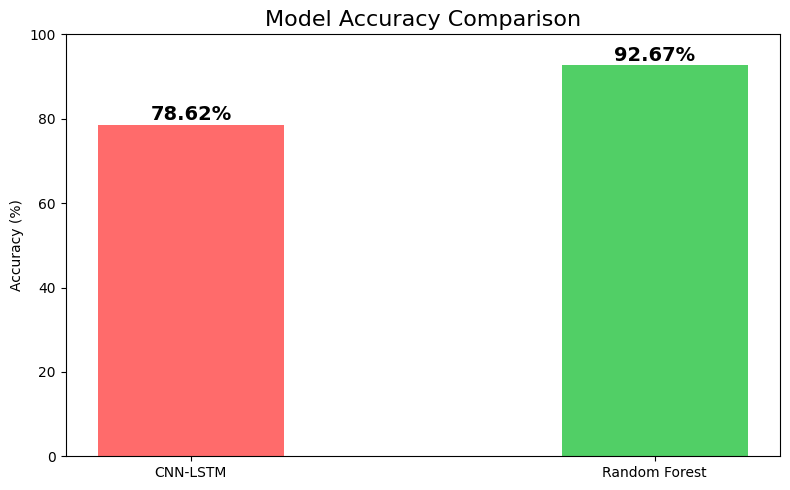

 Chart Saved!


In [13]:
import matplotlib.pyplot as plt

# Model Comparison Chart
models = ['CNN-LSTM', 'Random Forest']
accuracies = [78.62, 92.67]
colors = ['#FF6B6B', '#51CF66']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.4)
plt.title('Model Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy (%)')
plt.ylim([0, 100])

# Values show
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc}%', ha='center',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()
print(" Chart Saved!")

# 12 Detailed Classification Report

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Model Predict
predictions = rf_model.predict(X_test_rf)

# Detailed Report
print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_rf, predictions))

DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



# 13 Confusion Matrix

DETAILED CLASSIFICATION REPORT
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
           WALKING       0.89      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.87      0.92       420
  WALKING_UPSTAIRS       0.89      0.89      0.89       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.93      2947
      weighted avg       0.93      0.93      0.93      2947



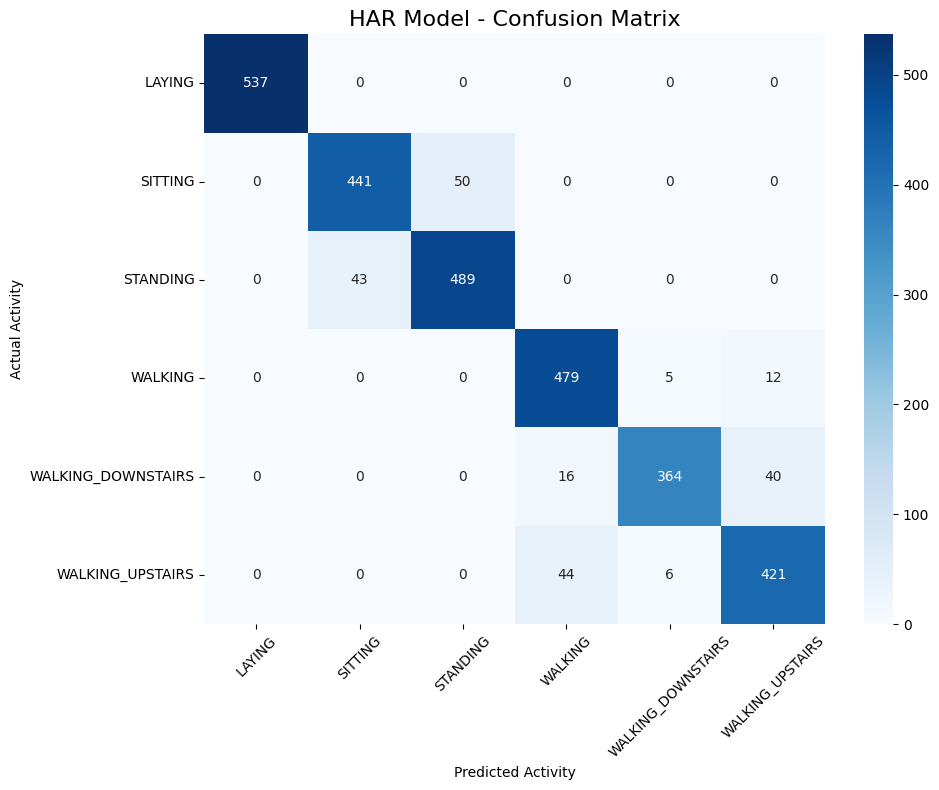

Done!


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Predictions — string labels convert
predictions = rf_model.predict(X_test_rf)

# Labels
activities = np.unique(y_test_rf)

print("DETAILED CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test_rf, predictions,
                            target_names=activities))

# Confusion Matrix
cm = confusion_matrix(y_test_rf, predictions,
                      labels=activities)
plt.figure(figsize=(10, 8))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=activities,
            yticklabels=activities)
plt.title('HAR Model - Confusion Matrix', fontsize=16)
plt.ylabel('Actual Activity')
plt.xlabel('Predicted Activity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()
print("Done!")

# 14 Cross Validation

In [16]:
from sklearn.model_selection import cross_val_score

print("CROSS VALIDATION")
print("="*60)

cv_scores = cross_val_score(
    rf_model,
    np.vstack([X_train_rf, X_test_rf]),
    np.concatenate([y_train_rf, y_test_rf]),
    cv=5,
    n_jobs=-1
)

print(f"CV Scores: {cv_scores}")
print(f"Mean Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Std: {cv_scores.std()*100:.2f}%")
print(f"Reliable Accuracy: "
      f"{(cv_scores.mean()-cv_scores.std())*100:.2f}% "
      f"- {(cv_scores.mean()+cv_scores.std())*100:.2f}%")

CROSS VALIDATION
CV Scores: [0.93834951 0.91941748 0.94514563 0.93203883 0.93346285]
Mean Accuracy: 93.37%
Std: 0.85%
Reliable Accuracy: 92.52% - 94.22%


# 15 HAR Model — Final Evaluation Report

In [17]:
import json
import os

# Final Summary Report
summary = {
    "model_name": "HAR Activity Detection Model",
    "dataset": "UCI HAR Dataset",
    "total_samples": {
        "train": 7352,
        "test": 2947
    },
    "model_comparison": {
        "Random_Forest": {
            "test_accuracy": 92.67,
            "cv_mean_accuracy": 93.37,
            "cv_std": 0.85,
            "cv_reliable_range": "92.52% - 94.22%"
        },
        "CNN_LSTM": {
            "test_accuracy": 78.62,
            "cv_mean_accuracy": "N/A"
        }
    },
    "best_model": "Random Forest",
    "per_activity_f1": {
        "LAYING": 1.00,
        "SITTING": 0.90,
        "STANDING": 0.91,
        "WALKING": 0.93,
        "WALKING_DOWNSTAIRS": 0.92,
        "WALKING_UPSTAIRS": 0.89
    },
    "overall_metrics": {
        "precision": 0.93,
        "recall": 0.93,
        "f1_score": 0.93,
        "accuracy": 0.93
    }
}

# Save
os.makedirs('/content/reports', exist_ok=True)
with open('/content/reports/har_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("HAR MODEL — COMPARISON REPORT")
print("="*60)
print(json.dumps(summary, indent=2))
print("\n Report Saved to /content/reports/har_summary.json")

HAR MODEL — COMPARISON REPORT
{
  "model_name": "HAR Activity Detection Model",
  "dataset": "UCI HAR Dataset",
  "total_samples": {
    "train": 7352,
    "test": 2947
  },
  "model_comparison": {
    "Random_Forest": {
      "test_accuracy": 92.67,
      "cv_mean_accuracy": 93.37,
      "cv_std": 0.85,
      "cv_reliable_range": "92.52% - 94.22%"
    },
    "CNN_LSTM": {
      "test_accuracy": 78.62,
      "cv_mean_accuracy": "N/A"
    }
  },
  "best_model": "Random Forest",
  "per_activity_f1": {
    "LAYING": 1.0,
    "SITTING": 0.9,
    "STANDING": 0.91,
    "WALKING": 0.93,
    "WALKING_DOWNSTAIRS": 0.92,
    "WALKING_UPSTAIRS": 0.89
  },
  "overall_metrics": {
    "precision": 0.93,
    "recall": 0.93,
    "f1_score": 0.93,
    "accuracy": 0.93
  }
}

 Report Saved to /content/reports/har_summary.json


# 16 Error Analysis

In [18]:
import pandas as pd

# Error Analysis
print("ERROR ANALYSIS")
print("="*60)

# Results DataFrame
results_df = pd.DataFrame({
    'actual': y_test_rf,
    'predicted': predictions
})

# Wrong Predictions
errors_df = results_df[
    results_df['actual'] != results_df['predicted']
].copy()

errors_df['pair'] = (errors_df['actual'] +
                     " → " +
                     errors_df['predicted'])

total = len(results_df)
errors = len(errors_df)

print(f"Total Samples  : {total}")
print(f"Correct        : {total - errors}")
print(f"Errors         : {errors}")
print(f"Error Rate     : {errors/total*100:.2f}%")
print(f"\n Top 10 Confusion Pairs:")
print(errors_df['pair'].value_counts().head(10).to_string())

ERROR ANALYSIS
Total Samples  : 2947
Correct        : 2731
Errors         : 216
Error Rate     : 7.33%

 Top 10 Confusion Pairs:
pair
SITTING → STANDING                       50
WALKING_UPSTAIRS → WALKING               44
STANDING → SITTING                       43
WALKING_DOWNSTAIRS → WALKING_UPSTAIRS    40
WALKING_DOWNSTAIRS → WALKING             16
WALKING → WALKING_UPSTAIRS               12
WALKING_UPSTAIRS → WALKING_DOWNSTAIRS     6
WALKING → WALKING_DOWNSTAIRS              5


# 17 Final Visualization

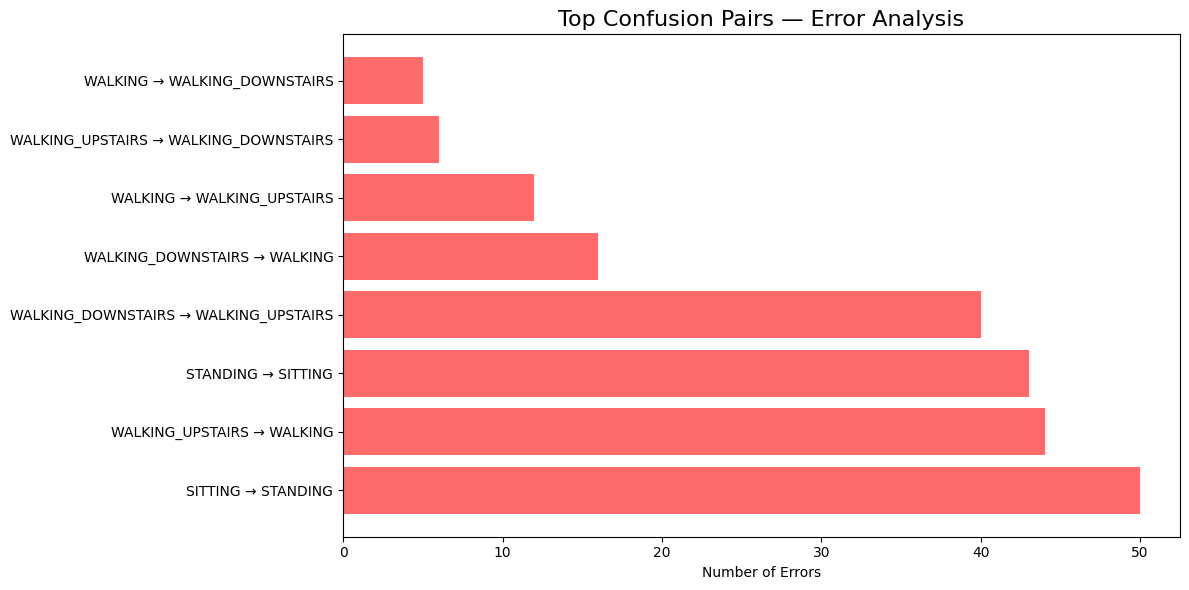

Error Analysis Chart Saved!


In [19]:
# Error Rate Chart
errors_top = errors_df['pair'].value_counts().head(8)

plt.figure(figsize=(12, 6))
bars = plt.barh(errors_top.index,
                errors_top.values,
                color='#FF6B6B')
plt.title('Top Confusion Pairs — Error Analysis',
          fontsize=16)
plt.xlabel('Number of Errors')
plt.tight_layout()
plt.savefig('error_analysis.png')
plt.show()

print("Error Analysis Chart Saved!")

# 18 Save & Download Results

In [20]:
from google.colab import files

# Download Reports
files.download('confusion_matrix.png')
files.download('error_analysis.png')
files.download('model_comparison.png')
files.download('/content/reports/har_summary.json')

print("All Files Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All Files Downloaded!


# 19 Model Save and Download


In [21]:
import joblib

joblib.dump(rf_model, 'har_model.pkl')
joblib.dump(le, 'har_label_encoder.pkl')

print("Models Saved!")

from google.colab import files
files.download('har_model.pkl')
files.download('har_label_encoder.pkl')

Models Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 20 Hyperparameter Tuning


In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score

param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rf_tuned = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=15,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train_rf, y_train_rf)

best_rf = rf_tuned.best_estimator_
tuned_acc = accuracy_score(y_test_rf, best_rf.predict(X_test_rf))

print(f"Best Parameters: {rf_tuned.best_params_}")
print(f"Original Accuracy : 92.67%")
print(f"Tuned Accuracy    : {tuned_acc*100:.2f}%")

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
Original Accuracy : 92.67%
Tuned Accuracy    : 93.76%


# 21 Tuned model save

In [23]:
import joblib

joblib.dump(best_rf, 'har_model_tuned.pkl')
print("Tuned Model Saved!")

from google.colab import files
files.download('har_model_tuned.pkl')

Tuned Model Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 22 Ensemble Model


In [24]:
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)

et = ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)

ensemble = VotingClassifier(
    estimators=[('rf', best_rf), ('et', et), ('gb', gb)],
    voting='soft',
    n_jobs=-1
)

ensemble.fit(X_train_rf, y_train_rf)
ens_acc = accuracy_score(y_test_rf, ensemble.predict(X_test_rf))

print(f"Original Accuracy : 92.67%")
print(f"Tuned RF Accuracy : 93.76%")
print(f"Ensemble Accuracy : {ens_acc*100:.2f}%")

Original Accuracy : 92.67%
Tuned RF Accuracy : 93.76%
Ensemble Accuracy : 94.44%


# 23 Ensemble Model Save

In [25]:
import joblib

joblib.dump(ensemble, 'har_model_ensemble.pkl')
print("Ensemble Model Saved!")

from google.colab import files
files.download('har_model_ensemble.pkl')

Ensemble Model Saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# 24 Accuracy Progression Chart


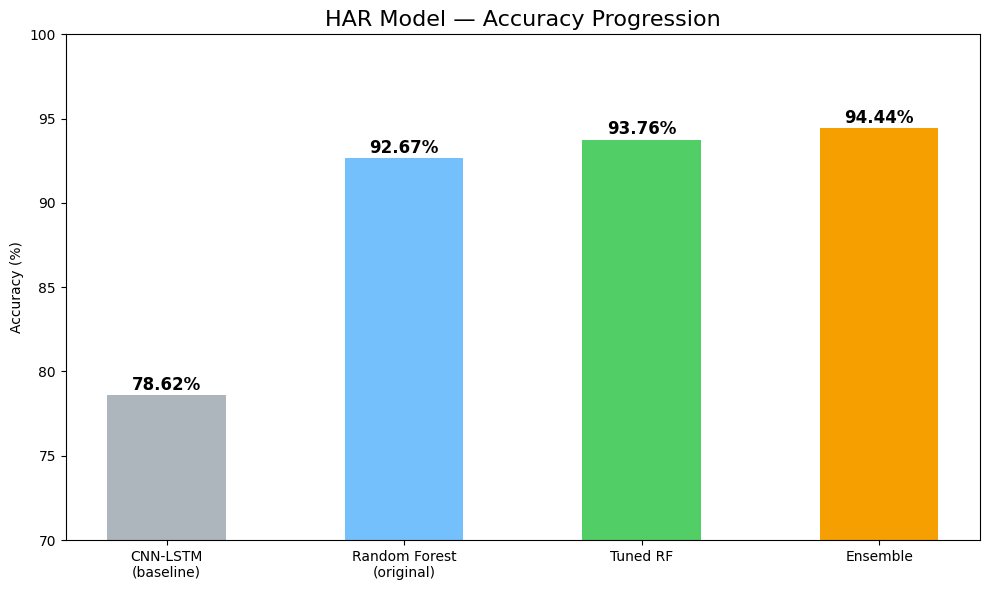

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
import matplotlib.pyplot as plt

models = ['CNN-LSTM\n(baseline)', 'Random Forest\n(original)',
          'Tuned RF', 'Ensemble']
accuracies = [78.62, 92.67, 93.76, 94.44]
colors = ['#adb5bd', '#74c0fc', '#51cf66', '#f59f00']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.title('HAR Model — Accuracy Progression', fontsize=16)
plt.ylabel('Accuracy (%)')
plt.ylim([70, 100])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc}%', ha='center',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('har_accuracy_progression.png', dpi=150)
plt.show()

from google.colab import files
files.download('har_accuracy_progression.png')